# Students Preformance Prediction

import the Python Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Creating a dataframe

In [2]:
data={
    "Student": ["S01","S02","S03","S04","S05","S06","S07","S08","S09","S10","S11","S12","S13","S14","S15"],
    "Study_Hours": [2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0],
    "Attendance": [65,70,72,75,78,80,82,85,87,88,90,92,94,95,96],
    "Assignments": [5,6,6,7,7,8,8,9,9,9,10,10,10,10,10],
    "Previous_Percentage": [55,58,60,62,65,68,70,72,75,77,80,82,85,87,90],
    "Final_Percentage": [58,61,64,67,70,73,76,79,82,84,87,89,92,94,96]
}
df=pd.DataFrame(data)
df.head()

,Student,Study_Hours,Attendance,Assignments,Previous_Percentage,Final_Percentage
0,S01,2.0,65,5,55,58
1,S02,2.5,70,6,58,61
2,S03,3.0,72,6,60,64
3,S04,3.5,75,7,62,67
4,S05,4.0,78,7,65,70


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student              15 non-null     object 
 1   Study_Hours          15 non-null     float64
 2   Attendance           15 non-null     int64  
 3   Assignments          15 non-null     int64  
 4   Previous_Percentage  15 non-null     int64  
 5   Final_Percentage     15 non-null     int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 852.0+ bytes


Data Preprocessing

In [4]:
X=df[["Study_Hours","Attendance","Assignments","Previous_Percentage"]]
y=df["Final_Percentage"]
print("Feature Variable",X.shape)
print("Target Variable",y.shape)


Feature Variable (15, 4)
Target Variable (15,)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_Scaled=scaler.fit_transform(X)

Feature Engineering

In [47]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=42)

In [48]:
print("Training Data")
print(x_train,y_train)

Training Data
    Study_Hours  Attendance  Assignments  Previous_Percentage
2           3.0          72            6                   60
1           2.5          70            6                   58
14          9.0          96           10                   90
4           4.0          78            7                   65
7           5.5          85            9                   72
10          7.0          90           10                   80
12          8.0          94           10                   85
3           3.5          75            7                   62
6           5.0          82            8                   70 2     64
1     61
14    96
4     70
7     79
10    87
12    92
3     67
6     76
Name: Final_Percentage, dtype: int64


In [49]:
print("Testing Data")
print(x_test,y_test)

Testing Data
    Study_Hours  Attendance  Assignments  Previous_Percentage
9           6.5          88            9                   77
11          7.5          92           10                   82
0           2.0          65            5                   55
13          8.5          95           10                   87
5           4.5          80            8                   68
8           6.0          87            9                   75 9     84
11    89
0     58
13    94
5     73
8     82
Name: Final_Percentage, dtype: int64


Model Selection and Training

In [50]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x_train,y_train)
y_test_pred=model.predict(x_test)
y_pred_all=model.predict(X)
print("Predicting the testing Data:",y_test_pred)
print("Predicting the training and testing Data:",y_pred_all)

Predicting the testing Data: [83.7682743  89.33232856 56.72230595 93.96156745 73.27807084 81.77053504]
Predicting the training and testing Data: [56.72230595 61.21929164 63.68236624 67.08025622 70.17709118 73.27807084
 75.74114544 79.13903542 81.77053504 83.7682743  86.86925396 89.33232856
 91.96382818 93.96156745 96.12773173]


Model Evaluation

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae=mean_absolute_error(y_test,y_test_pred)
mse=mean=mean_squared_error(y_test,y_test_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_test_pred)

In [54]:
print("Mean Absolute Error:",mae)
print("\nMean Squared Error:",mse)
print("\nRoot Mean Squared Error:",rmse)
print("\nR²:",r2)

Mean Absolute Error: 0.397952775684504

Mean Squared Error: 0.3213492944160003

Root Mean Squared Error: 0.5668767894489951

R²: 0.9976769930524144


Visualization

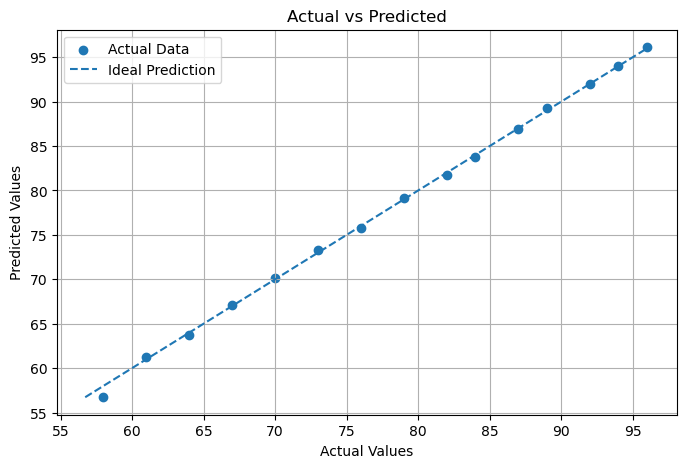

In [55]:
import matplotlib.pyplot as plt
indices = np.arange(len(y))
plt.figure(figsize=(8,5))
plt.scatter(y,y_pred_all,label="Actual Data")
minimum = min(y.min(), y_pred_all.min())
maximum = max(y.max(), y_pred_all.max())
plt.plot([minimum, maximum],[minimum, maximum],linestyle="--",label="Ideal Prediction")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()